
# Influence-based Royalty Allocation (Revised)

This notebook allocates royalties to training points based on their **influence scores** on generated samples.

**Data layout**
- `S` has shape `[N_train, N_gen]` (here: `[28000, 500]`).
- Column `j` holds the influence of every training point `i` on generated sample `j`.
- Per-sample allocations are aggregated into a final **royalty distribution** over the training set.

**Allocation families**
- **Top-K (equal split):** each generated sample pays only its Top-K most influential training points, evenly.
- **Top-K (proportional):** each generated sample pays only its Top-K, proportionally to their (preprocessed) scores.
- **Inverse-ranking:** weights are `1 / rank^p` (optionally capped at top-`m`), then normalized per sample.
- **Soft-power weighting:** weights proportional to `score^alpha`, normalized per sample.

**Inequality metrics**
- **Gini coefficient**
- **Atkinson index** (\\(\\epsilon\\in\\{0.5, 1.0, 2.0\\}\\))
- **Herfindahl–Hirschman Index (HHI)**
- Top 1% / 10% share, max share

**Visualizations (only)**
- Lorenz curve
- Histogram of royalties

> Notes:
> - Default preprocessing uses **positive-only** influence (`ReLU`) so that negative influence does not receive royalties.
> - If, for a generated sample, all (preprocessed) influences are zero, that sample contributes nothing; final distributions are re-normalized to sum to 1.


In [1]:

import math
from typing import Dict

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:,.6f}")


In [2]:

# --- Configuration ---
S_PATH = "checkpoints_subset_large/score_LoGra_4096_gen.pt"
N_TRAIN = 28000
N_GEN = 500

# Preprocess influences before allocation:
#   'positive' : clamp negatives to 0 (default)
#   'shift'    : shift by global min so the minimum becomes 0
#   'absolute' : use absolute values
#   'raw'      : use raw influences as-is
PREPROCESS = "positive"

# Optional: weights per generated sample (e.g., by importance). If None, all equal.
SAMPLE_WEIGHTS = None  # torch.Tensor of shape [N_GEN] or None

PARAMS = {
    "topk_equal": {"k": 500},
    "topk_prop":  {"k": 500},
    "inverse_rank": {"m": 500, "p": 1.0},
    "soft_power": {"alpha": 1.0},
}

DEVICE = "cpu"


In [3]:

# --- Load S ---
S = torch.load(S_PATH, map_location=DEVICE)
assert S.ndim == 2, "Expected 2D tensor [N_train, N_gen]"
print("Loaded S with shape:", tuple(S.shape), "dtype:", S.dtype)


ipykernel_3070589/448449236.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  S = torch.load(S_PATH, map_location=DEVICE)


Loaded S with shape: (28000, 500) dtype: torch.float32


In [4]:

# --- Preprocessing & utilities ---
def preprocess_scores(S: torch.Tensor, mode: str = "positive") -> torch.Tensor:
    if mode == "positive":
        return torch.clamp(S, min=0)
    if mode == "shift":
        return S - torch.min(S)
    if mode == "absolute":
        return torch.abs(S)
    if mode == "raw":
        return S
    raise ValueError("Unknown preprocess mode")

def column_normalize(W: torch.Tensor) -> torch.Tensor:
    col_sums = W.sum(dim=0, keepdim=True)
    W = torch.where(col_sums > 0, W / col_sums, W)
    return W

def aggregate(W: torch.Tensor, sample_weights: torch.Tensor = None) -> torch.Tensor:
    if sample_weights is None:
        p = W.sum(dim=1)
    else:
        p = (W * sample_weights[None, :]).sum(dim=1)
    p = p / p.sum()
    return p

# Metrics
def gini(x: torch.Tensor) -> float:
    n = x.numel()
    xs = torch.sort(x)[0]
    i = torch.arange(1, n + 1, dtype=xs.dtype, device=xs.device)
    G = (2 * torch.sum(i * xs) / (n * torch.sum(xs))) - (n + 1) / n
    return float(G)

def atkinson(x: torch.Tensor, epsilon: float) -> float:
    mu = x.mean()
    if epsilon == 1.0:
        gm = torch.exp(torch.mean(torch.log(torch.clamp(x, min=1e-20))))
        return float(1.0 - (gm / mu))
    p = 1.0 - epsilon
    term = torch.mean(torch.pow(x, p))
    return float(1.0 - (term ** (1.0 / p)) / mu)

def top_share(x: torch.Tensor, frac: float) -> float:
    n = x.numel()
    k = max(1, int(round(frac * n)))
    xs = torch.sort(x, descending=True)[0]
    return float(xs[:k].sum().item())

def hhi(x: torch.Tensor) -> float:
    return float(torch.sum(x * x).item())

# Visualization helpers (only Lorenz + Histogram)
def plot_lorenz(x: torch.Tensor, title: str):
    xs = torch.sort(x)[0]
    cumx = torch.cumsum(xs, dim=0)
    n = xs.numel()
    lorenz_x = np.linspace(0, 1, n + 1)
    lorenz_y = np.concatenate([[0.0], cumx.cpu().numpy() / cumx[-1].item()])
    plt.figure()
    plt.plot(lorenz_x, lorenz_y, linewidth=2)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"Lorenz Curve — {title}")
    plt.xlabel("Population share")
    plt.ylabel("Cumulative royalty share")
    plt.show()

def plot_hist(x: torch.Tensor, title: str, bins: int = 100):
    plt.figure()
    plt.hist(x.cpu().numpy(), bins=bins)
    plt.yscale("log")
    plt.title(f"Royalty Distribution Histogram — {title}")
    plt.xlabel("Royalty share per training point")
    plt.ylabel("Count (log scale)")
    plt.show()


In [5]:

# --- Allocation methods ---
def precompute_order(Spp: torch.Tensor) -> torch.Tensor:
    return torch.argsort(Spp, dim=0, descending=True)

def allocate_topk_equal(Spp: torch.Tensor, k: int, idx_desc: torch.Tensor = None) -> torch.Tensor:
    if idx_desc is None:
        idx_desc = precompute_order(Spp)
    W = torch.zeros_like(Spp)
    top_idx = idx_desc[:k, :]
    W.scatter_(0, top_idx, torch.ones_like(top_idx, dtype=Spp.dtype))
    W = W / k
    return column_normalize(W)

def allocate_topk_prop(Spp: torch.Tensor, k: int, idx_desc: torch.Tensor = None) -> torch.Tensor:
    if idx_desc is None:
        idx_desc = precompute_order(Spp)
    W = torch.zeros_like(Spp)
    top_idx = idx_desc[:k, :]
    top_vals = Spp.gather(0, top_idx)
    col_norm = top_vals.sum(dim=0, keepdim=True)
    weights = torch.where(col_norm > 0, top_vals / col_norm, torch.zeros_like(top_vals))
    W.scatter_(0, top_idx, weights)
    return column_normalize(W)

def allocate_inverse_rank(Spp: torch.Tensor, m: int = None, p: float = 1.0, idx_desc: torch.Tensor = None) -> torch.Tensor:
    n, g = Spp.shape
    if idx_desc is None:
        idx_desc = precompute_order(Spp)
    ranks = torch.arange(1, n + 1, device=Spp.device, dtype=Spp.dtype).unsqueeze(1).expand(n, g)
    weights = 1.0 / torch.pow(ranks, p)
    if m is not None:
        weights[m:, :] = 0.0
    W = torch.zeros_like(Spp)
    W.scatter_(0, idx_desc, weights)
    return column_normalize(W)

def allocate_soft_power(Spp: torch.Tensor, alpha: float = 1.0) -> torch.Tensor:
    W = torch.pow(Spp, alpha)
    return column_normalize(W)


In [6]:

# --- Run methods & metrics ---
Spp = preprocess_scores(S, PREPROCESS).to(DEVICE)
idx_desc = precompute_order(Spp)
sample_weights = SAMPLE_WEIGHTS if SAMPLE_WEIGHTS is None else SAMPLE_WEIGHTS.to(DEVICE)

methods = {
    "Top-K (equal)": allocate_topk_equal(Spp, **PARAMS["topk_equal"], idx_desc=idx_desc),
    "Top-K (proportional)": allocate_topk_prop(Spp, **PARAMS["topk_prop"], idx_desc=idx_desc),
    "Inverse-ranking": allocate_inverse_rank(Spp, **PARAMS["inverse_rank"], idx_desc=idx_desc),
    "Soft-power": allocate_soft_power(Spp, **PARAMS["soft_power"]),
}

results: Dict[str, Dict] = {}
for name, W in methods.items():
    p = aggregate(W, sample_weights=sample_weights)
    metrics = {
        "Gini": gini(p),
        "Atkinson (eps=0.5)": atkinson(p, 0.5),
        "Atkinson (eps=1.0)": atkinson(p, 1.0),
        "Atkinson (eps=2.0)": atkinson(p, 2.0),
        "Top 1% share": top_share(p, 0.01),
        "Top 10% share": top_share(p, 0.10),
        "Max share": float(p.max().item()),
        "HHI": hhi(p),
    }
    results[name] = {"p": p, "metrics": metrics}

summary_df = pd.DataFrame({k: v["metrics"] for k, v in results.items()}).T
summary_df = summary_df[["Gini", "Atkinson (eps=0.5)", "Atkinson (eps=1.0)", "Atkinson (eps=2.0)", "Top 1% share", "Top 10% share", "Max share", "HHI"]]
summary_df.sort_values("Gini", ascending=False, inplace=True)
summary_df


,Gini,Atkinson (eps=0.5),Atkinson (eps=1.0),Atkinson (eps=2.0),Top 1% share,Top 10% share,Max share,HHI
Inverse-ranking,0.563411,0.262424,0.476034,1.000000,0.107548,0.456713,0.000926,0.000122
Top-K (proportional),0.311340,0.081155,0.219208,1.000000,0.032171,0.221769,0.000212,0.000048
Top-K (equal),0.261840,0.058670,0.177753,1.000000,0.026196,0.195760,0.000144,0.000044
Soft-power,0.112871,0.010368,0.020732,0.041798,0.017286,0.141253,0.000101,0.000037


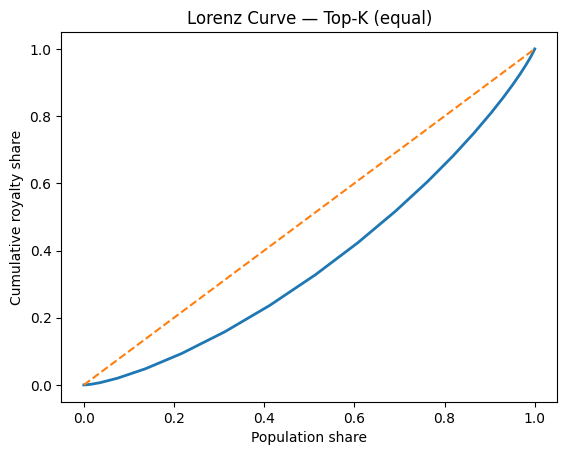

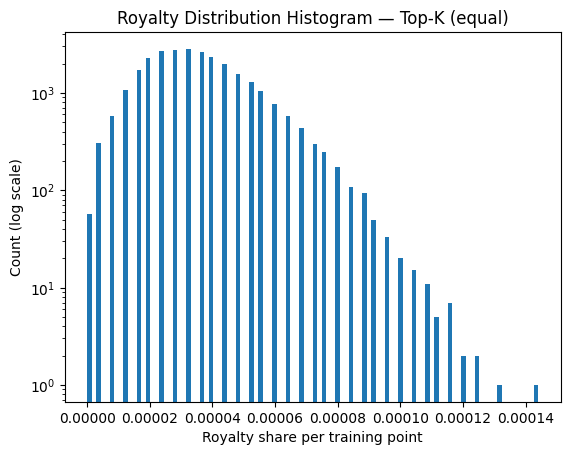

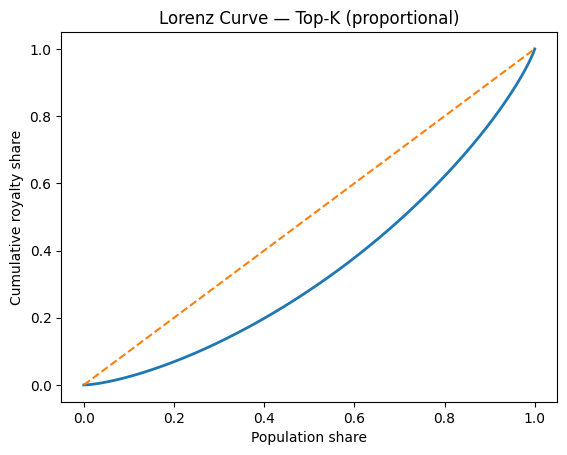

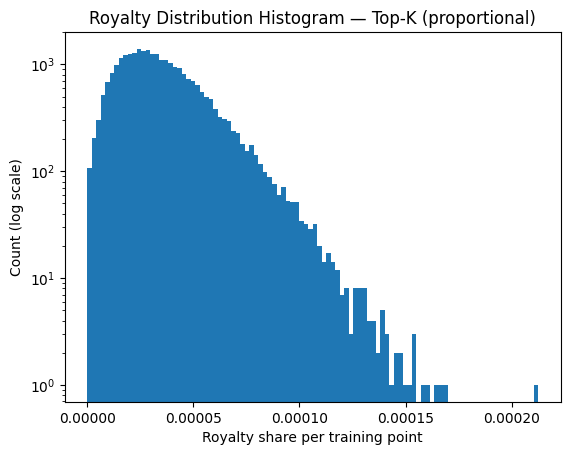

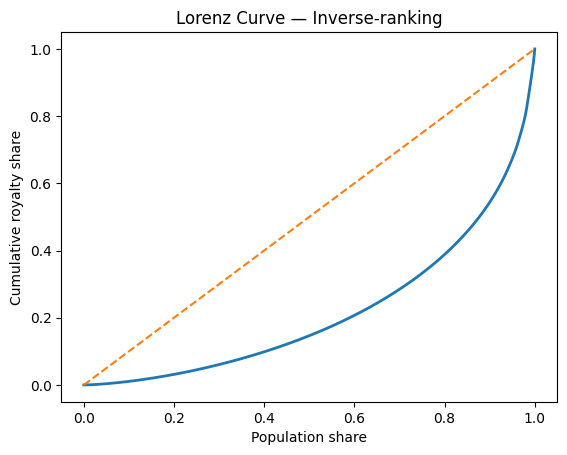

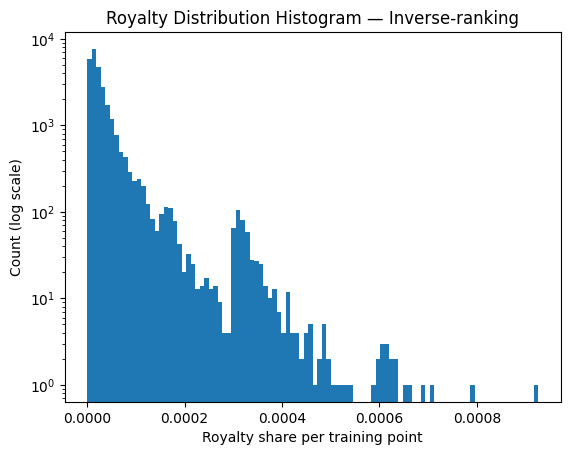

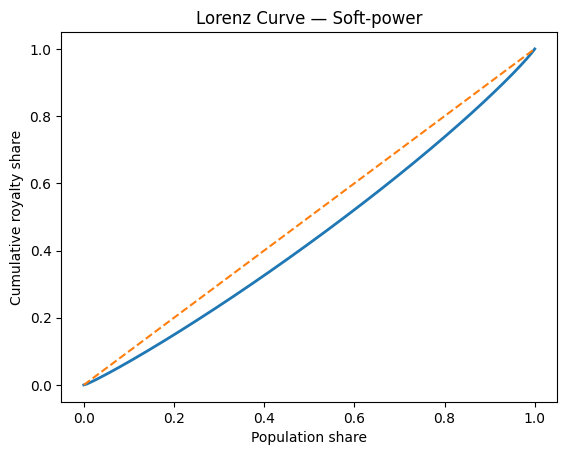

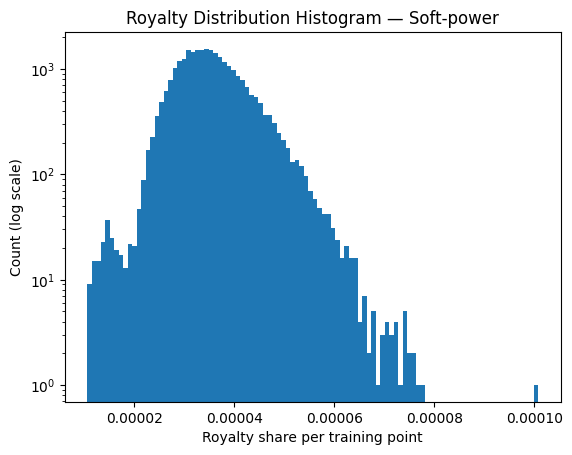

In [7]:

# --- Visualizations (Lorenz + Histogram only) ---
for name, obj in results.items():
    p = obj["p"]
    plot_lorenz(p, name)
    plot_hist(p, name, bins=100)



## Sensitivity Analyses

We sweep key hyperparameters and track inequality metrics.


In [8]:

# --- Top-K sweep ---
K_list = [1, 10, 50, 100, 500]
rows = []
for k in K_list:
    W = allocate_topk_equal(Spp, k=k, idx_desc=idx_desc)
    p = aggregate(W, sample_weights=sample_weights)
    rows.append({"K": k, "Gini": gini(p), "Top 1% share": top_share(p, 0.01), "Top 10% share": top_share(p, 0.10)})
topk_sweep_df = pd.DataFrame(rows)
topk_sweep_df


,K,Gini,Top 1% share,Top 10% share
0,1,0.983384,0.596000,1.000000
1,10,0.863830,0.129600,0.694800
2,50,0.597069,0.056640,0.353600
3,100,0.465949,0.042680,0.282140
4,500,0.261840,0.026196,0.195760


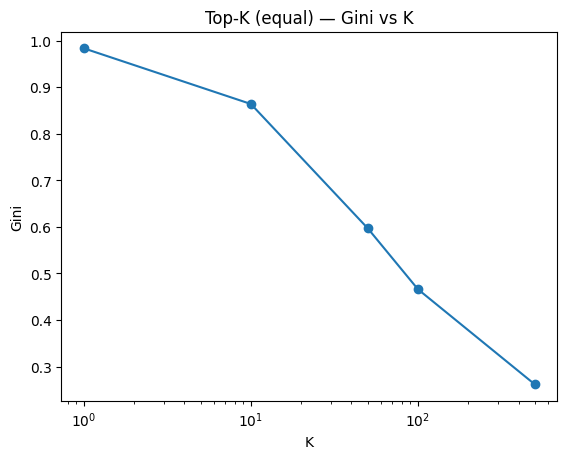

In [9]:

plt.figure()
plt.plot(topk_sweep_df["K"], topk_sweep_df["Gini"], marker="o")
plt.title("Top-K (equal) — Gini vs K")
plt.xlabel("K")
plt.ylabel("Gini")
plt.xscale("log")
plt.show()


In [10]:

# --- Inverse-ranking sweep over p ---
P_list = [0.5, 1.0, 1.5, 2.0]
rows = []
for pwr in P_list:
    W = allocate_inverse_rank(Spp, m=PARAMS["inverse_rank"]["m"], p=pwr, idx_desc=idx_desc)
    p = aggregate(W, sample_weights=sample_weights)
    rows.append({"p": pwr, "Gini": gini(p), "Top 1% share": top_share(p, 0.01), "Top 10% share": top_share(p, 0.10)})
inv_sweep_df = pd.DataFrame(rows)
inv_sweep_df


,p,Gini,Top 1% share,Top 10% share
0,0.500000,0.316469,0.034725,0.229053
1,1.000000,0.563411,0.107548,0.456713
2,1.500000,0.825838,0.253867,0.769659
3,2.000000,0.930363,0.375504,0.924446


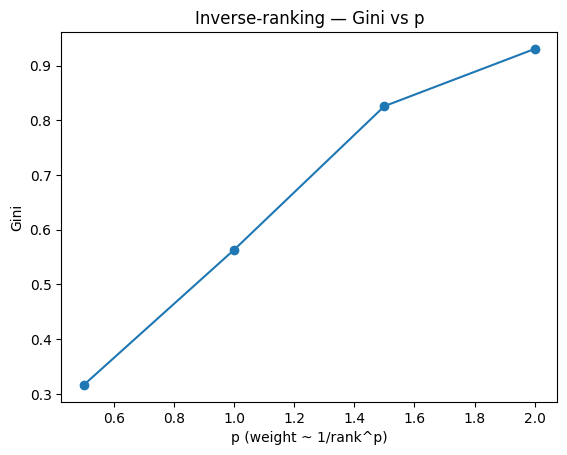

In [11]:

plt.figure()
plt.plot(inv_sweep_df["p"], inv_sweep_df["Gini"], marker="o")
plt.title("Inverse-ranking — Gini vs p")
plt.xlabel("p (weight ~ 1/rank^p)")
plt.ylabel("Gini")
plt.show()


In [12]:

# --- Soft-power sweep over alpha ---
ALPHA_list = [0.5, 1.0, 2.0, 4.0]
rows = []
for a in ALPHA_list:
    W = allocate_soft_power(Spp, alpha=a)
    p = aggregate(W, sample_weights=sample_weights)
    rows.append({"alpha": a, "Gini": gini(p), "Top 1% share": top_share(p, 0.01), "Top 10% share": top_share(p, 0.10)})
soft_sweep_df = pd.DataFrame(rows)
soft_sweep_df


,alpha,Gini,Top 1% share,Top 10% share
0,0.500000,0.056547,0.012965,0.118562
1,1.000000,0.112871,0.017286,0.141253
2,2.000000,0.386233,0.059638,0.296466
3,4.000000,0.780323,0.190670,0.658549


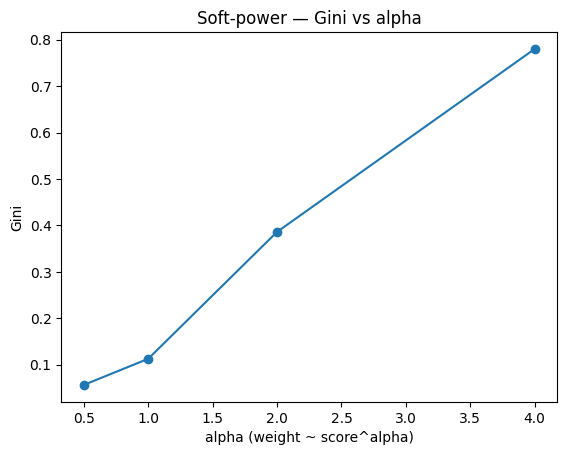

In [13]:

plt.figure()
plt.plot(soft_sweep_df["alpha"], soft_sweep_df["Gini"], marker="o")
plt.title("Soft-power — Gini vs alpha")
plt.xlabel("alpha (weight ~ score^alpha)")
plt.ylabel("Gini")
plt.show()


In [14]:
# --- Map training sample IDs to usernames and aggregate royalties per user ---
import warnings

TRAIN_PATH = "datasets/finetune/train_v2.txt"
META_CSV = "tt_data_hashed.csv"
ID_COL = "ID"           # column name in META_CSV holding hashed id
USER_COL = "artist"     # treat artist as username per sample

# 1) Parse training sample ids: last whitespace-separated token per line
train_ids = []
with open(TRAIN_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        tok = line.split()
        train_ids.append(tok[-1])

train_ids = pd.Series(train_ids, name="id")

# Validate length vs N_TRAIN
if len(train_ids) != N_TRAIN:
    warnings.warn(f"Parsed {len(train_ids)} ids from train file, but N_TRAIN={N_TRAIN}.")

# 2) Load id->username mapping
meta = pd.read_csv(META_CSV)
if ID_COL not in meta.columns or USER_COL not in meta.columns:
    raise ValueError(f"CSV must contain columns '{ID_COL}' and '{USER_COL}'. Columns: {list(meta.columns)}")

id_to_user = pd.Series(meta[USER_COL].values, index=meta[ID_COL].values)

# 3) Build mapping for all training ids, warning on misses
users = []
num_missing = 0
missing_examples = []
for tid in train_ids:
    if tid in id_to_user.index:
        users.append(id_to_user.loc[tid])
    else:
        users.append(None)
        num_missing += 1
        if len(missing_examples) < 5:
            missing_examples.append(tid)

if num_missing > 0:
    warnings.warn(
        f"{num_missing} / {len(train_ids)} training ids not found in metadata. Examples: {missing_examples}"
    )

users = pd.Series(users, name="user")

# 4) Convert per-training-point royalty vectors to DataFrame
# 'results' dict exists from previous cells: { method: { 'p': tensor, 'metrics': ... } }
royalty_frames = {}
for method_name, obj in results.items():
    p = obj["p"].detach().cpu().numpy()
    df = pd.DataFrame({"id": train_ids.values, "user": users.values, "royalty": p})
    royalty_frames[method_name] = df

# 5) Aggregate by user (ignoring missing users)
user_aggregates = {}
for method_name, df in royalty_frames.items():
    agg = df.dropna(subset=["user"]).groupby("user", as_index=False)["royalty"].sum()
    agg.sort_values("royalty", ascending=False, inplace=True)
    agg.reset_index(drop=True, inplace=True)
    user_aggregates[method_name] = agg

# 6) Display top users per method
TOP_N = 20
for method_name, agg in user_aggregates.items():
    print(f"\n=== Top {TOP_N} users — {method_name} ===")
    display(agg.head(TOP_N))



=== Top 20 users — Top-K (equal) ===


ipykernel_3070589/327694596.py:46: UserWarning: 4 / 28000 training ids not found in metadata. Examples: ['Abm__yYQmak', 'Abm__yYQmak', 'Abm__yYQmak', 'Abm__yYQmak']
  warnings.warn(


,user,royalty
0,Nintendo,0.012612
1,Taylor Swift,0.010808
2,ZUN,0.009500
3,MIKA,0.007488
4,Toby Fox,0.007280
5,Mother Mother,0.007020
6,Madonna,0.006308
7,Kevin MacLeod,0.006304
8,Lady Gaga,0.006284
9,Sega,0.006172



=== Top 20 users — Top-K (proportional) ===


,user,royalty
0,Nintendo,0.012665
1,Taylor Swift,0.011247
2,ZUN,0.010023
3,MIKA,0.007693
4,Toby Fox,0.007276
5,Mother Mother,0.006605
6,Lady Gaga,0.006577
7,Madonna,0.006386
8,Sega,0.006360
9,Kevin MacLeod,0.005982



=== Top 20 users — Inverse-ranking ===


,user,royalty
0,Nintendo,0.013390
1,ZUN,0.011728
2,Taylor Swift,0.011695
3,MIKA,0.009068
4,Sega,0.007771
5,Lady Gaga,0.007623
6,Toby Fox,0.007622
7,Madonna,0.007015
8,The Beatles,0.005736
9,The Hush Sound,0.005687



=== Top 20 users — Soft-power ===


,user,royalty
0,Nintendo,0.013548
1,Taylor Swift,0.012859
2,ZUN,0.010084
3,Mother Mother,0.007176
4,Toby Fox,0.006973
5,MIKA,0.006872
6,Kevin MacLeod,0.006707
7,Sega,0.006080
8,The Beatles,0.005595
9,Josh Woodward,0.005458



Top-K (equal):
  Original users: 2610, Filtered users: 697
  Total dataset_share (before renorm): 0.354622
  Total royalty_share (before renorm): 0.361705


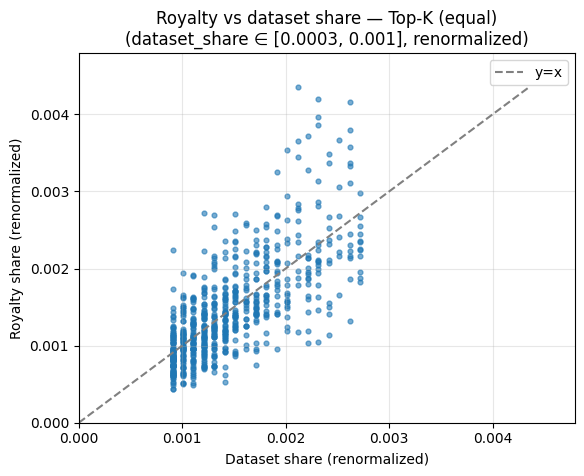


Top-K (proportional):
  Original users: 2610, Filtered users: 697
  Total dataset_share (before renorm): 0.354622
  Total royalty_share (before renorm): 0.358235


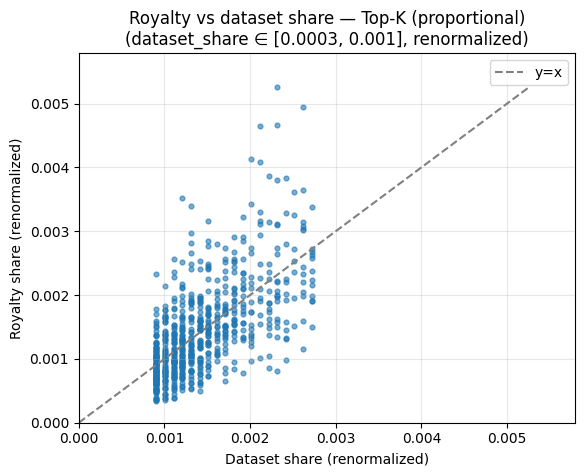


Inverse-ranking:
  Original users: 2610, Filtered users: 697
  Total dataset_share (before renorm): 0.354622
  Total royalty_share (before renorm): 0.349054


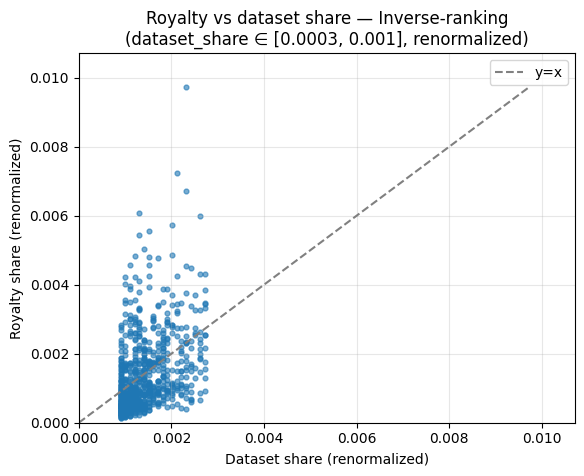


Soft-power:
  Original users: 2610, Filtered users: 697
  Total dataset_share (before renorm): 0.354622
  Total royalty_share (before renorm): 0.356838


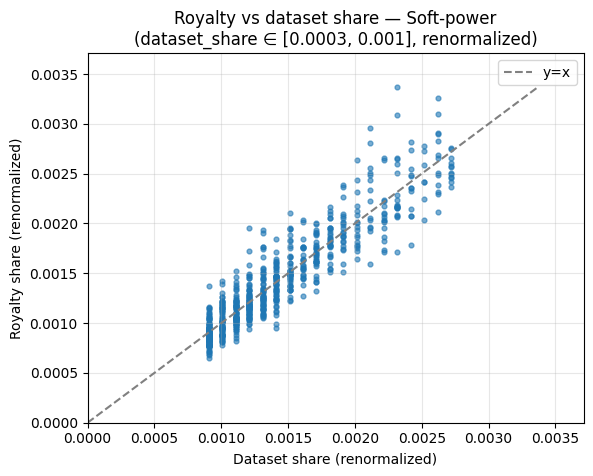

In [15]:
DS_MIN = 0.0003
DS_MAX = 0.0010

for method_n, agg_df in user_aggregates.items():
    
    agg_m = agg_df.copy()
    agg_m["royalty_share"] = agg_m["royalty"] / agg_m["royalty"].sum()
    
    dataset_share_m = (
        users.dropna()
             .value_counts(normalize=True)
             .rename_axis("user")
             .reset_index(name="dataset_share")
    )
    merged_m = pd.merge(agg_m[["user", "royalty_share"]], dataset_share_m, on="user", how="left").fillna({"dataset_share": 0.0})
    
    mask_ds = (merged_m["dataset_share"] >= DS_MIN) & (merged_m["dataset_share"] <= DS_MAX)
    filtered_m = merged_m[mask_ds].copy()
    
    if len(filtered_m) == 0:
        print(f"Warning: No users in range [{DS_MIN}, {DS_MAX}] for {method_n}")
        continue
    
    total_dataset_filtered = filtered_m["dataset_share"].sum()
    total_royalty_filtered = filtered_m["royalty_share"].sum()
    filtered_m["dataset_share_renorm"] = filtered_m["dataset_share"] / total_dataset_filtered
    filtered_m["royalty_share_renorm"] = filtered_m["royalty_share"] / total_royalty_filtered
    
    print(f"\n{method_n}:")
    print(f"  Original users: {len(merged_m)}, Filtered users: {len(filtered_m)}")
    print(f"  Total dataset_share (before renorm): {total_dataset_filtered:.6f}")
    print(f"  Total royalty_share (before renorm): {total_royalty_filtered:.6f}")
    
    plt.figure()
    plt.scatter(filtered_m["dataset_share_renorm"], filtered_m["royalty_share_renorm"], s=12, alpha=0.6)
    
    max_val = float(max(filtered_m["dataset_share_renorm"].max(), filtered_m["royalty_share_renorm"].max()))
    plt.plot([0, max_val], [0, max_val], "--", color="gray", label="y=x")
    
    plt.xlim(0, max_val * 1.1)
    plt.ylim(0, max_val * 1.1)
    plt.xlabel("Dataset share (renormalized)")
    plt.ylabel("Royalty share (renormalized)")
    plt.title(f"Royalty vs dataset share — {method_n}\n(dataset_share ∈ [{DS_MIN}, {DS_MAX}], renormalized)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


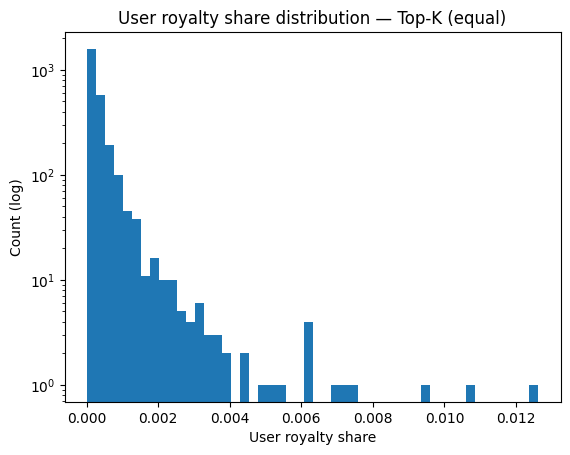

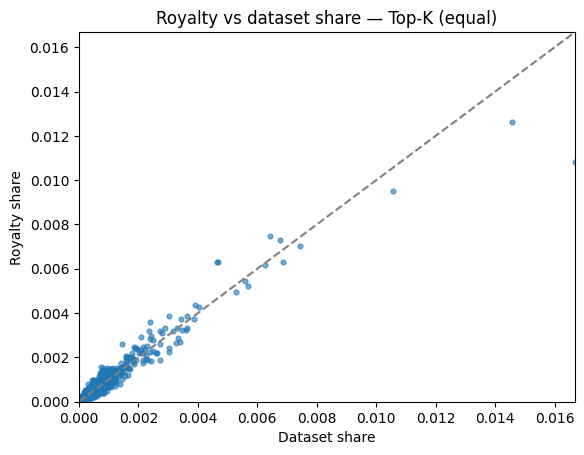

,user,royalty_share,dataset_share,uplift_rel,uplift_ratio
1882,Semi,0.000116,0.000036,2.248121,3.248121
1314,Krin,0.000204,0.000071,1.856106,2.856106
2033,Kreepa,0.000100,0.000036,1.800104,2.800104
2028,The Black Angels,0.000100,0.000036,1.800104,2.800104
1344,New Order,0.000196,0.000071,1.744102,2.744102
957,Catch 22,0.000280,0.000107,1.613431,2.613431
2120,One Direction,0.000092,0.000036,1.576096,2.576096
973,Cold Turkey,0.000276,0.000107,1.576096,2.576096
240,David Guetta ft Sia,0.000812,0.000321,1.526316,2.526316
569,josh mancell,0.000436,0.000179,1.441691,2.441691


,user,royalty_share,dataset_share,uplift_rel,uplift_ratio
2608,Sure Sure,0.000016,0.000143,-0.887996,0.112004
2607,Hareton Salvanini,0.000016,0.000107,-0.850661,0.149339
2418,Alexander Courage,0.000056,0.000286,-0.803993,0.196007
2598,Surasshu and Stemage,0.000024,0.000107,-0.775992,0.224008
2595,Erik Satie,0.000024,0.000107,-0.775992,0.224008
2605,kd lang,0.000016,0.000071,-0.775992,0.224008
2515,Villa-Lobos,0.000040,0.000179,-0.775992,0.224008
2547,The Clash,0.000036,0.000143,-0.747991,0.252009
2541,Jia Jia,0.000036,0.000143,-0.747991,0.252009
2584,Lucas Pope,0.000028,0.000107,-0.738657,0.261343


In [16]:
# --- Royalty distribution (user-level) and royalty vs dataset share ---
# Pick a method to visualize (default to Soft-power if available)
method_name = "Top-K (equal)" if "Top-K (equal)" in user_aggregates else next(iter(user_aggregates))
agg = user_aggregates[method_name].copy()

# Normalize to royalty share per user
agg["royalty_share"] = agg["royalty"] / agg["royalty"].sum()

# Dataset share per user (fraction of training samples)
dataset_share = (
    users.dropna()
         .value_counts(normalize=True)
         .rename_axis("user")
         .reset_index(name="dataset_share")
)
merged = pd.merge(agg[["user", "royalty_share"]], dataset_share, on="user", how="left").fillna({"dataset_share": 0.0})

# 1) Histogram of user royalty shares
plt.figure()
plt.hist(agg["royalty_share"], bins=50)
plt.yscale("log")
plt.xlabel("User royalty share")
plt.ylabel("Count (log)")
plt.title(f"User royalty share distribution — {method_name}")
plt.show()

# 2) Scatter: royalty share vs dataset share (y=x reference)
plt.figure()
plt.scatter(merged["dataset_share"], merged["royalty_share"], s=12, alpha=0.6)
max_val = float(max(merged["dataset_share"].max(), merged["royalty_share"].max()))
plt.plot([0, max_val], [0, max_val], "--", color="gray")
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.xlabel("Dataset share")
plt.ylabel("Royalty share")
plt.title(f"Royalty vs dataset share — {method_name}")
plt.show()

# Top/bottom relative uplift: (royalty_share - dataset_share) / dataset_share
merged["uplift_rel"] = np.where(
    merged["dataset_share"] > 0,
    (merged["royalty_share"] - merged["dataset_share"]) / merged["dataset_share"],
    np.nan,
)
# Also provide ratio for reference
merged["uplift_ratio"] = np.where(
    merged["dataset_share"] > 0,
    merged["royalty_share"] / merged["dataset_share"],
    np.nan,
)
display(merged.sort_values("uplift_rel", ascending=False).head(10))
display(merged.sort_values("uplift_rel").head(10))


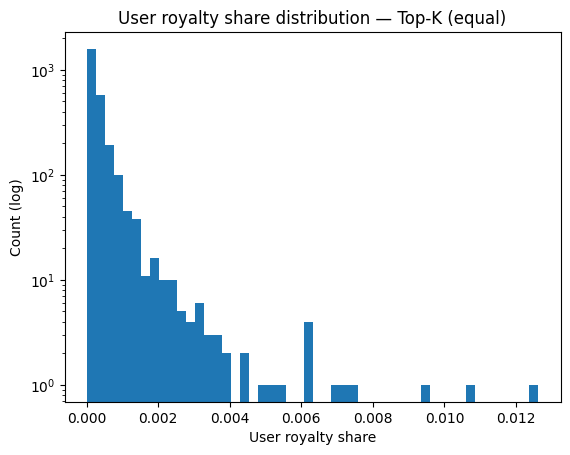

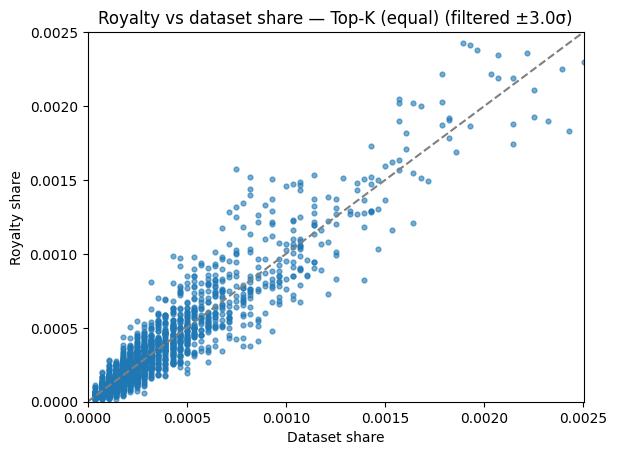

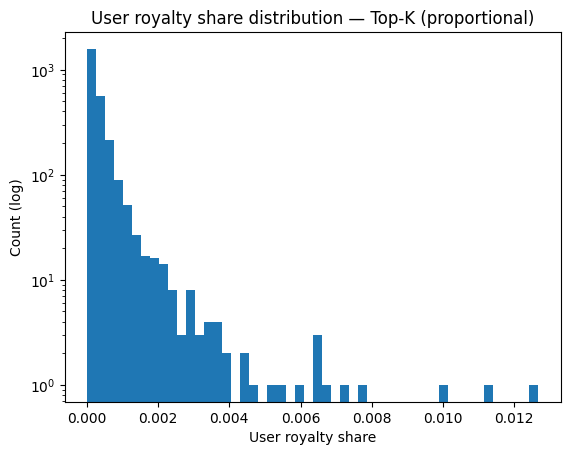

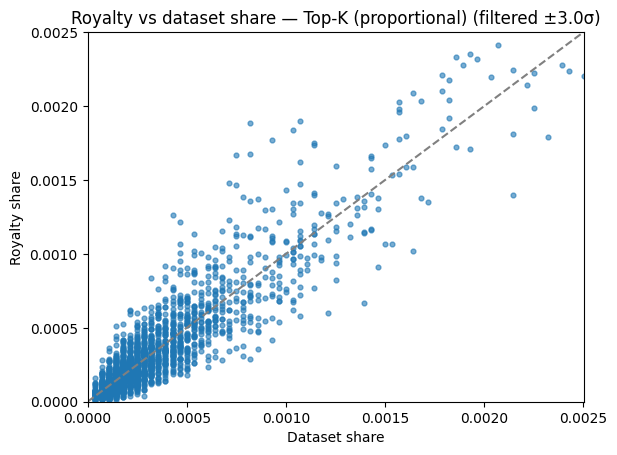

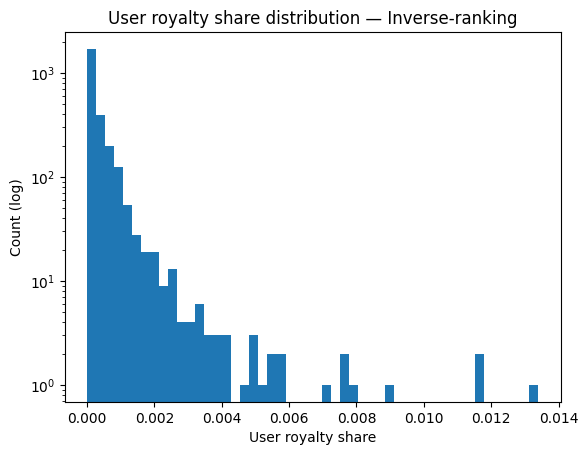

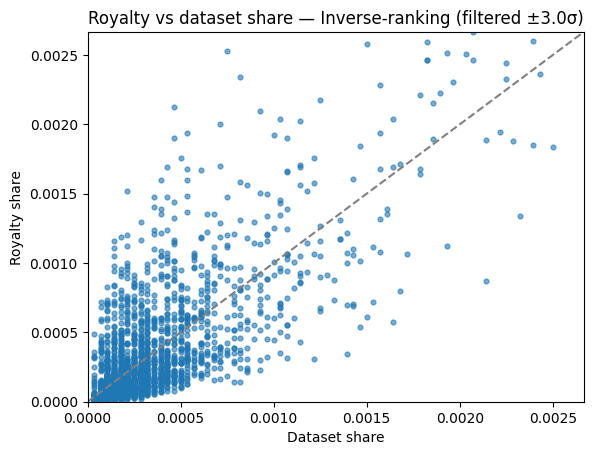

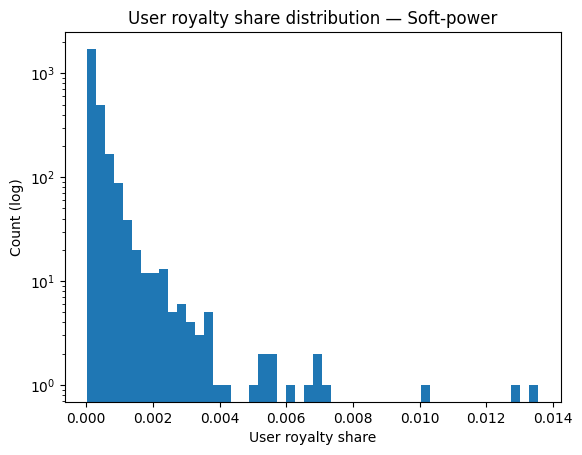

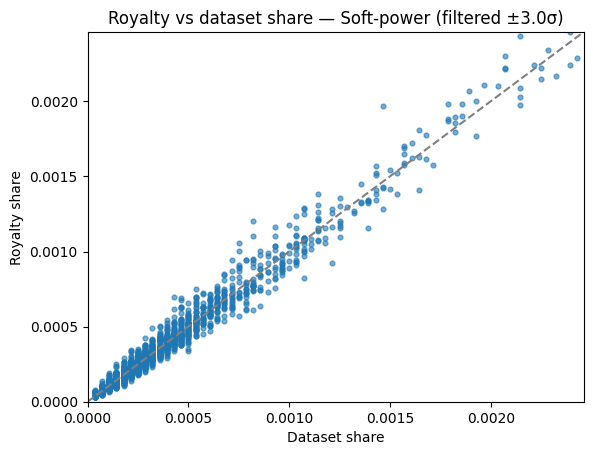

In [17]:
# --- Additional user-level plots for other allocation methods ---
# For each method in user_aggregates (except the one already plotted above),
# draw: (1) histogram of user royalty share, (2) scatter royalty vs dataset share.

for method_n, agg_df in user_aggregates.items():

    agg_m = agg_df.copy()
    agg_m["royalty_share"] = agg_m["royalty"] / agg_m["royalty"].sum()

    dataset_share_m = (
        users.dropna()
             .value_counts(normalize=True)
             .rename_axis("user")
             .reset_index(name="dataset_share")
    )
    merged_m = pd.merge(agg_m[["user", "royalty_share"]], dataset_share_m, on="user", how="left").fillna({"dataset_share": 0.0})

    # 1) Histogram of user royalty shares
    plt.figure()
    plt.hist(agg_m["royalty_share"], bins=50)
    plt.yscale("log")
    plt.xlabel("User royalty share")
    plt.ylabel("Count (log)")
    plt.title(f"User royalty share distribution — {method_n}")
    plt.show()

    # 2) Scatter: royalty share vs dataset share (y=x reference)
    # Optional outlier filtering
    FILTER_OUTLIERS = True
    N_SIGMA = 3.0
    
    merged_plot = merged_m.copy()
    if FILTER_OUTLIERS:
        ds_mean, ds_std = merged_plot["dataset_share"].mean(), merged_plot["dataset_share"].std()
        rs_mean, rs_std = merged_plot["royalty_share"].mean(), merged_plot["royalty_share"].std()
        mask = (
            (merged_plot["dataset_share"] >= ds_mean - N_SIGMA * ds_std) &
            (merged_plot["dataset_share"] <= ds_mean + N_SIGMA * ds_std) &
            (merged_plot["royalty_share"] >= rs_mean - N_SIGMA * rs_std) &
            (merged_plot["royalty_share"] <= rs_mean + N_SIGMA * rs_std)
        )
        merged_plot = merged_plot[mask]
        title_suffix = f" (filtered ±{N_SIGMA}σ)"
    else:
        title_suffix = ""
    
    plt.figure()
    plt.scatter(merged_plot["dataset_share"], merged_plot["royalty_share"], s=12, alpha=0.6)
    max_val = float(max(merged_plot["dataset_share"].max(), merged_plot["royalty_share"].max()))
    plt.plot([0, max_val], [0, max_val], "--", color="gray")
    plt.xlim(0, max_val)
    plt.ylim(0, max_val)
    plt.xlabel("Dataset share")
    plt.ylabel("Royalty share")
    plt.title(f"Royalty vs dataset share — {method_n}{title_suffix}")
    plt.show()


In [18]:
# --- Print all training clips (IDs) and song names for specified artists ---

# def print_artist_clips(artist_name: str):
#     ids_in_train = set(train_ids.values)
#     m = (meta["artist"] == artist_name) & (meta["ID"].isin(ids_in_train))
#     rows = meta.loc[m, ["ID", "song"]]
#     print(f"\nArtist: {artist_name} — {len(rows)} clips in training set")
#     for _id, song in rows.itertuples(index=False):
#         print(f"{_id}\t{song}")

# print_artist_clips("ZUN")


In [19]:
# --- Diagnose dataset_share vs printed clips discrepancy ---
# dataset_share is based on frequency in the training list (lines), while the print used distinct IDs.
# This cell shows, for each artist, occurrences by line vs distinct IDs, and top repeated IDs.

def diagnose_artist(artist_name: str):
    mask = (users == artist_name)
    num_occurrences = int(mask.sum())
    num_total = int(users.notna().sum())
    share_by_lines = (num_occurrences / num_total) if num_total else float("nan")

    ids_for_artist = train_ids[mask]
    num_distinct_ids = int(ids_for_artist.nunique())

    # dataset_share used in previous merged table (if present)
    ds_val = merged.loc[merged["user"] == artist_name, "dataset_share"]
    ds_val = float(ds_val.iloc[0]) if len(ds_val) else float("nan")

    print(f"Artist: {artist_name}")
    print(f"- Occurrences in training list (lines): {num_occurrences} / {num_total} = {share_by_lines:.6f}")
    print(f"- Distinct IDs in training: {num_distinct_ids}")
    print(f"- merged.dataset_share: {ds_val:.6f}")

    # Top repeated IDs for this artist
    vc = ids_for_artist.value_counts()
    if len(vc) > 0:
        # Build mapping from meta
        id_to_song = pd.Series(meta["song"].values, index=meta["ID"].values)
        # Reset index and robustly name the ID column
        top = vc.rename("count").reset_index()
        id_col = top.columns[0]
        top.rename(columns={id_col: "ID"}, inplace=True)
        top["song"] = top["ID"].map(id_to_song)
        print("Top repeated IDs (count, ID, song):")
        display(top.head(10))

# print()
# diagnose_artist("TAILOR SWIFT")
# print()
# diagnose_artist("Taylor Swift")


In [20]:
# --- Play all ZUN mp3s by training line index mapping ---
# import os
# from IPython.display import Audio, display

# BASE_MP3_DIR = "datasets/finetune/song_train_mp3"
# artist_key = "zun"

# mask = users.fillna("").str.lower().eq(artist_key)
# idxs = np.nonzero(mask.values)[0]
# print(f"Artist '{artist_key.upper()}': {len(idxs)} clips in training (0-based line indices)")

# # Map line index -> ID -> song
# id_series = train_ids.iloc[idxs].reset_index(drop=True).rename("ID")
# id_to_song = pd.Series(meta["song"].values, index=meta["ID"].values)
# song_series = id_series.map(id_to_song).rename("song")
# line_series = pd.Series(idxs, name="line_idx")
# zun_df = pd.concat([line_series, id_series, song_series], axis=1)
# zun_df["mp3"] = zun_df["line_idx"].apply(lambda i: os.path.join(BASE_MP3_DIR, f"{i:06d}.mp3"))
# zun_df["exists"] = zun_df["mp3"].map(os.path.exists)

# # Print mapping lines
# for row in zun_df.itertuples(index=False):
#     print(f"{row.line_idx}\t{row.ID}\t{row.song}")

# # Play audios that exist
# for p in zun_df.loc[zun_df["exists"], "mp3"][:12]:
#     display(Audio(filename=p))


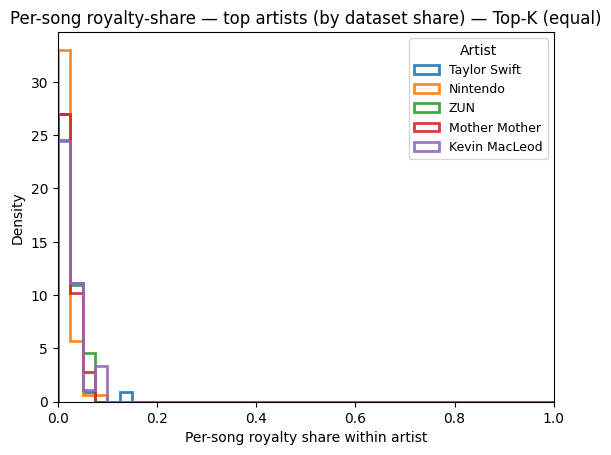

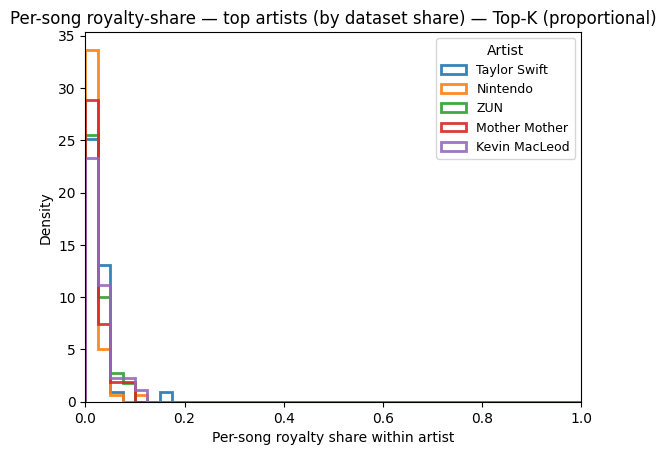

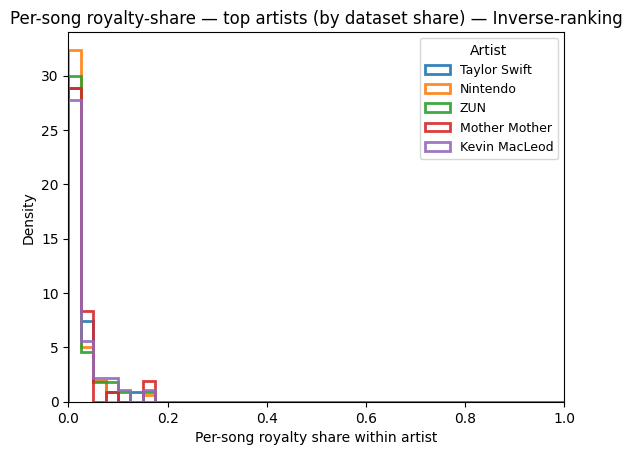

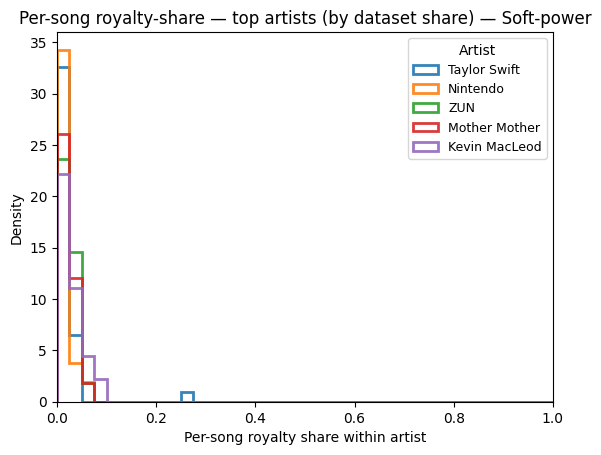

In [21]:
# --- Overlay per-song royalty-share histograms for top artists (by dataset share) ---
# For each allocation method, pick top-N artists by dataset share (frequency in training list),
# compute per-song royalty share within each artist, and overlay density histograms.

TOP_ARTISTS = 5
BINS = np.linspace(0.0, 1.0, 41)

# Build ID -> song mapping
id_to_song = pd.Series(meta["song"].values, index=meta["ID"].values)

# Rank artists by dataset share (based on training list occurrences)
ds_tbl = (
    users.dropna()
         .value_counts(normalize=True)
         .rename_axis("user")
         .reset_index(name="dataset_share")
         .sort_values("dataset_share", ascending=False)
)
top_artists = ds_tbl["user"].head(TOP_ARTISTS).tolist()

for method_n, df_m in royalty_frames.items():
    # Join song names
    dfj = df_m.copy()
    dfj["song"] = dfj["id"].map(id_to_song)
    dfj = dfj.dropna(subset=["user", "song"])  # keep rows with artist and song

    plt.figure()
    for artist in top_artists:
        sub = dfj.loc[dfj["user"] == artist, ["song", "royalty"]]
        if sub.empty:
            continue
        per_song = sub.groupby("song", as_index=False)["royalty"].sum()
        total = per_song["royalty"].sum()
        if total <= 0:
            continue
        vals = (per_song["royalty"] / total).to_numpy()
        plt.hist(
            vals,
            bins=BINS,
            density=True,
            histtype="step",
            linewidth=2,
            alpha=0.9,
            label=str(artist),
        )

    plt.xlabel("Per-song royalty share within artist")
    plt.ylabel("Density")
    plt.title(f"Per-song royalty-share — top artists (by dataset share) — {method_n}")
    plt.legend(title="Artist", fontsize=9)
    plt.xlim(0, 1)
    plt.yscale("linear")
    plt.show()


In [22]:
K_values = [1, 10, 100, 500]
allocation_configs = [
    ("Top-K (equal)", "topk_equal"),
    ("Top-K (proportional)", "topk_prop"),
    ("Inverse-ranking (p=1)", "inverse_rank")
]

rows = []
for method_name, method_key in allocation_configs:
    for k in K_values:
        if method_key == "topk_equal":
            W = allocate_topk_equal(Spp, k=k, idx_desc=idx_desc)
        elif method_key == "topk_prop":
            W = allocate_topk_prop(Spp, k=k, idx_desc=idx_desc)
        elif method_key == "inverse_rank":
            W = allocate_inverse_rank(Spp, m=k, p=1.0, idx_desc=idx_desc)
        
        p = aggregate(W, sample_weights=sample_weights)
        
        rows.append({
            "Method": method_name,
            "K": k,
            "Gini": gini(p),
            "Top 1% share": top_share(p, 0.01),
            "Top 10% share": top_share(p, 0.10),
            "Top 50% share": top_share(p, 0.50),
        })

comparison_df = pd.DataFrame(rows)
comparison_df


,Method,K,Gini,Top 1% share,Top 10% share,Top 50% share
0,Top-K (equal),1,0.983384,0.596000,1.000000,1.000000
1,Top-K (equal),10,0.863830,0.129600,0.694800,1.000000
2,Top-K (equal),100,0.465949,0.042680,0.282140,0.842360
3,Top-K (equal),500,0.261840,0.026196,0.195760,0.684740
4,Top-K (proportional),1,0.983384,0.596000,1.000000,1.000000
5,Top-K (proportional),10,0.876106,0.146721,0.749185,1.000000
6,Top-K (proportional),100,0.513429,0.051102,0.316689,0.862657
7,Top-K (proportional),500,0.311340,0.032171,0.221769,0.718522
8,Inverse-ranking (p=1),1,0.983384,0.596000,1.000000,1.000000
9,Inverse-ranking (p=1),10,0.914186,0.226627,0.875937,1.000000


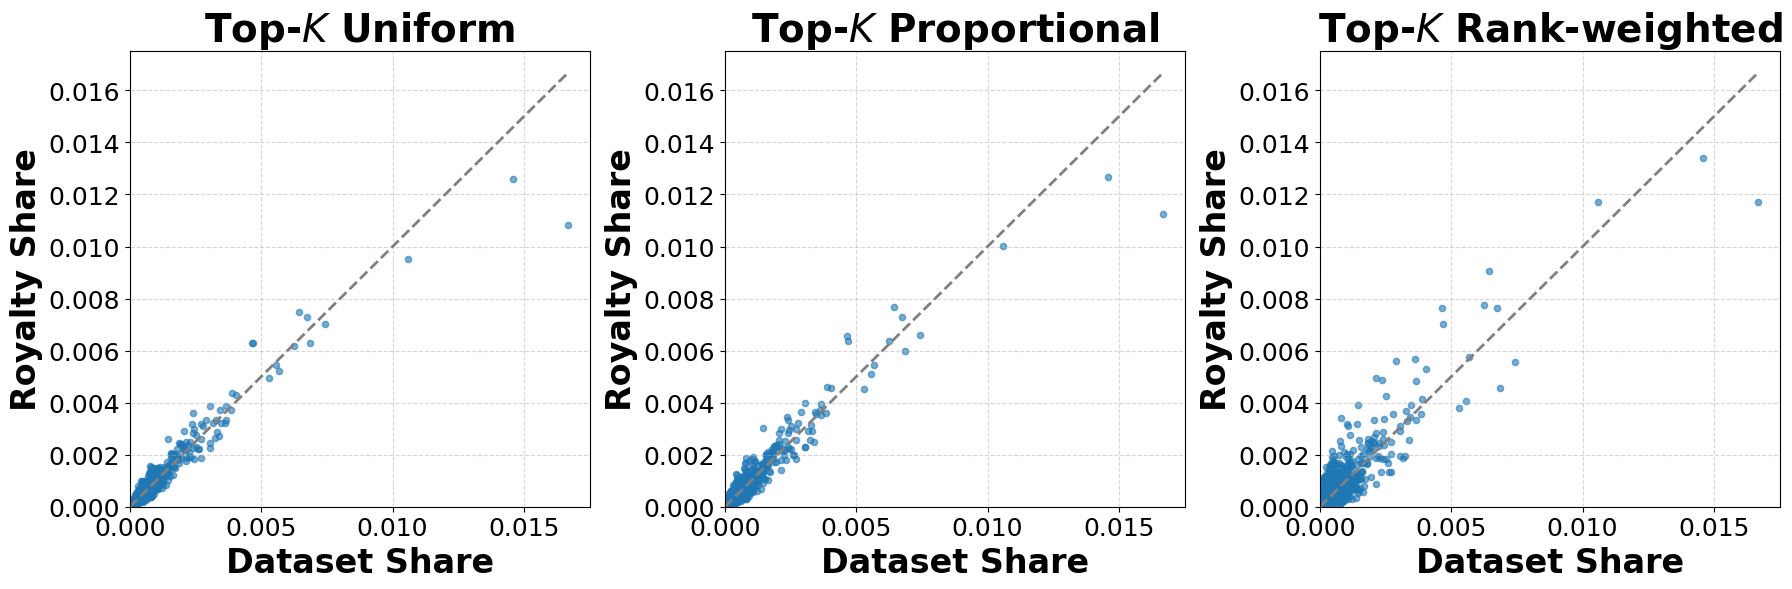

In [29]:
K = 500
methods_to_plot = [
    ("Top-$K$ Uniform", allocate_topk_equal(Spp, k=K, idx_desc=idx_desc)),
    ("Top-$K$ Proportional", allocate_topk_prop(Spp, k=K, idx_desc=idx_desc)),
    ("Top-$K$ Rank-weighted", allocate_inverse_rank(Spp, m=K, p=1.0, idx_desc=idx_desc)),
]

dataset_share_df = (
    users.dropna()
         .value_counts(normalize=True)
         .rename_axis("user")
         .reset_index(name="dataset_share")
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (method_name, W) in zip(axes, methods_to_plot):
    p = aggregate(W, sample_weights=sample_weights)
    
    royalty_df = pd.DataFrame({
        "id": train_ids.values,
        "user": users.values,
        "royalty": p.detach().cpu().numpy()
    })
    user_royalty = royalty_df.dropna(subset=["user"]).groupby("user", as_index=False)["royalty"].sum()
    user_royalty["royalty_share"] = user_royalty["royalty"] / user_royalty["royalty"].sum()
    
    merged = pd.merge(user_royalty[["user", "royalty_share"]], dataset_share_df, on="user", how="left").fillna({"dataset_share": 0.0})
    
    ax.scatter(merged["dataset_share"], merged["royalty_share"], s=20, alpha=0.6)
    max_val = float(max(merged["dataset_share"].max(), merged["royalty_share"].max()))
    ax.plot([0, max_val], [0, max_val], "--", color="gray", linewidth=2)
    ax.set_xlim(0, max_val * 1.05)
    ax.set_ylim(0, max_val * 1.05)
    ax.set_xlabel("Dataset Share", fontsize=24, fontweight="bold")
    ax.set_ylabel("Royalty Share", fontsize=24, fontweight="bold")
    ax.set_title(method_name, fontsize=28, fontweight="bold")
    ax.tick_params(axis="both", labelsize=18)
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("royalty_vs_dataset_share.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [24]:
# --- Fetch artist popularity from Spotify ---
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
import time

# Set your Spotify API credentials (replace with your own)
SPOTIFY_CLIENT_ID = "c6db7db7d9b64c73809622f8687359f6"
SPOTIFY_CLIENT_SECRET = "3d929e6eece84441a06325dff86a0ea4"

# Initialize Spotify client
sp = spotipy.Spotify(auth_manager=SpotifyClientCredentials(
    client_id=SPOTIFY_CLIENT_ID,
    client_secret=SPOTIFY_CLIENT_SECRET
))

# def get_artist_popularity(artist_name: str) -> float:
#     """Query Spotify for artist and return popularity (0-100), or NaN if not found."""
#     try:
#         results = sp.search(q=f"artist:{artist_name}", type="artist", limit=1)
#         if results["artists"]["items"]:
#             return float(results["artists"]["items"][0]["popularity"])
#         return float("nan")
#     except Exception as e:
#         print(f"Error fetching {artist_name}: {e}")
#         return float("nan")

# # Get unique artists from user_aggregates
# unique_artists = set()
# for method_n, agg_df in user_aggregates.items():
#     unique_artists.update(agg_df["user"].dropna().unique())
# unique_artists = sorted(unique_artists)

# print(f"Fetching popularity for {len(unique_artists)} unique artists...")

# # Fetch popularity with rate limiting
# artist_popularity = {}
# for i, artist in enumerate(unique_artists):
#     if (i + 1) % 50 == 0:
#         print(f"Progress: {i + 1}/{len(unique_artists)}")
#         time.sleep(1)  # Rate limiting
#     artist_popularity[artist] = get_artist_popularity(artist)

# # Convert to Series for easy merging
# popularity_series = pd.Series(artist_popularity, name="spotify_popularity")
# print(f"Fetched popularity for {popularity_series.notna().sum()} / {len(unique_artists)} artists")
# --- Optional: Save/load popularity data to avoid re-fetching ---
POPULARITY_CACHE = "artist_popularity_cache.pkl"

import pickle
# To load in future runs, uncomment:
with open(POPULARITY_CACHE, "rb") as f:
    artist_popularity = pickle.load(f)
popularity_series = pd.Series(artist_popularity, name="spotify_popularity")


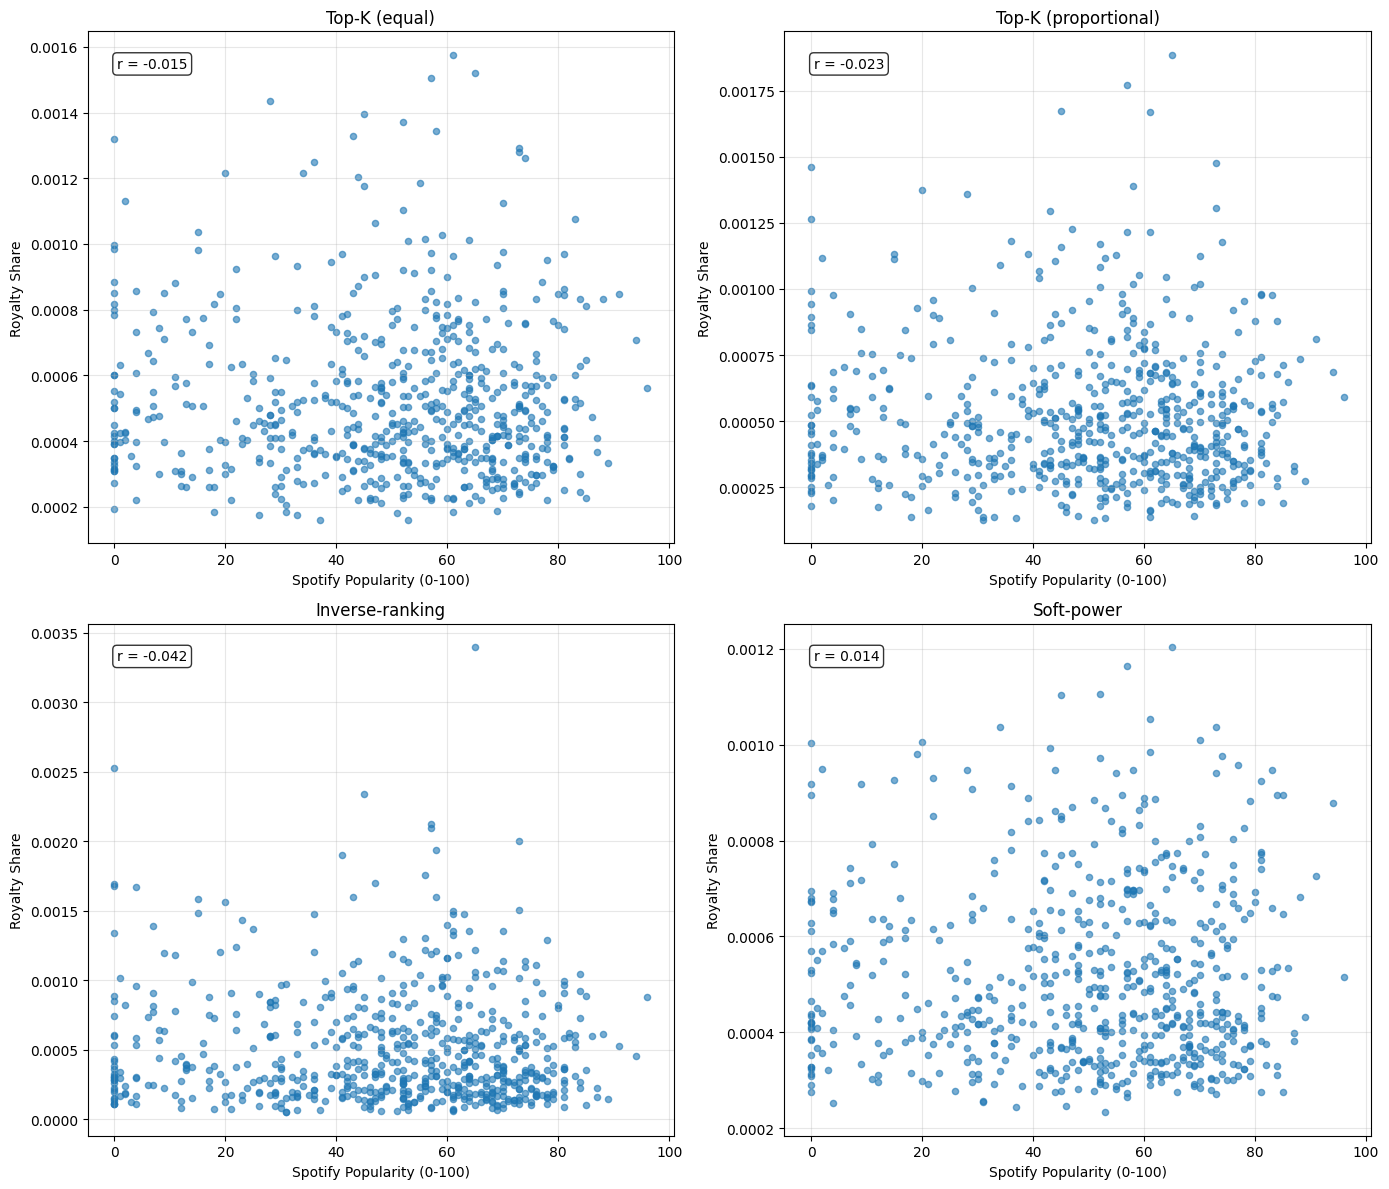


=== Royalty Share vs Spotify Popularity Correlations (filtered) ===
Top-K (equal): -0.0150 (n=642)
Top-K (proportional): -0.0232 (n=642)
Inverse-ranking: -0.0416 (n=642)
Soft-power: 0.0136 (n=642)


In [25]:
DS_MIN = 0.0003
DS_MAX = 0.0010

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

dataset_share_full = (
    users.dropna()
         .value_counts(normalize=True)
         .rename_axis("user")
         .reset_index(name="dataset_share")
)

for idx, (method_n, agg_df) in enumerate(user_aggregates.items()):
    agg_m = agg_df.copy()
    agg_m["royalty_share"] = agg_m["royalty"] / agg_m["royalty"].sum()
    
    agg_m = pd.merge(agg_m, dataset_share_full, on="user", how="left").fillna({"dataset_share": 0.0})
    
    mask_ds = (agg_m["dataset_share"] >= DS_MIN) & (agg_m["dataset_share"] <= DS_MAX)
    agg_m = agg_m[mask_ds].copy()
    
    agg_m["spotify_popularity"] = agg_m["user"].map(popularity_series)
    plot_data = agg_m.dropna(subset=["spotify_popularity"])
    
    ax = axes[idx]
    ax.scatter(plot_data["spotify_popularity"], plot_data["royalty_share"], s=20, alpha=0.6)
    ax.set_xlabel("Spotify Popularity (0-100)")
    ax.set_ylabel("Royalty Share")
    ax.set_title(f"{method_n}")
    ax.grid(True, alpha=0.3)
    
    if len(plot_data) > 1:
        corr = plot_data[["spotify_popularity", "royalty_share"]].corr().iloc[0, 1]
        ax.text(0.05, 0.95, f"r = {corr:.3f}", transform=ax.transAxes, 
                verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

print("\n=== Royalty Share vs Spotify Popularity Correlations (filtered) ===")
for method_n, agg_df in user_aggregates.items():
    agg_m = agg_df.copy()
    agg_m["royalty_share"] = agg_m["royalty"] / agg_m["royalty"].sum()
    
    agg_m = pd.merge(agg_m, dataset_share_full, on="user", how="left").fillna({"dataset_share": 0.0})
    
    mask_ds = (agg_m["dataset_share"] >= DS_MIN) & (agg_m["dataset_share"] <= DS_MAX)
    agg_m = agg_m[mask_ds].copy()
    
    agg_m["spotify_popularity"] = agg_m["user"].map(popularity_series)
    plot_data = agg_m.dropna(subset=["spotify_popularity"])
    
    if len(plot_data) > 1:
        corr = plot_data[["spotify_popularity", "royalty_share"]].corr().iloc[0, 1]
        print(f"{method_n}: {corr:.4f} (n={len(plot_data)})")


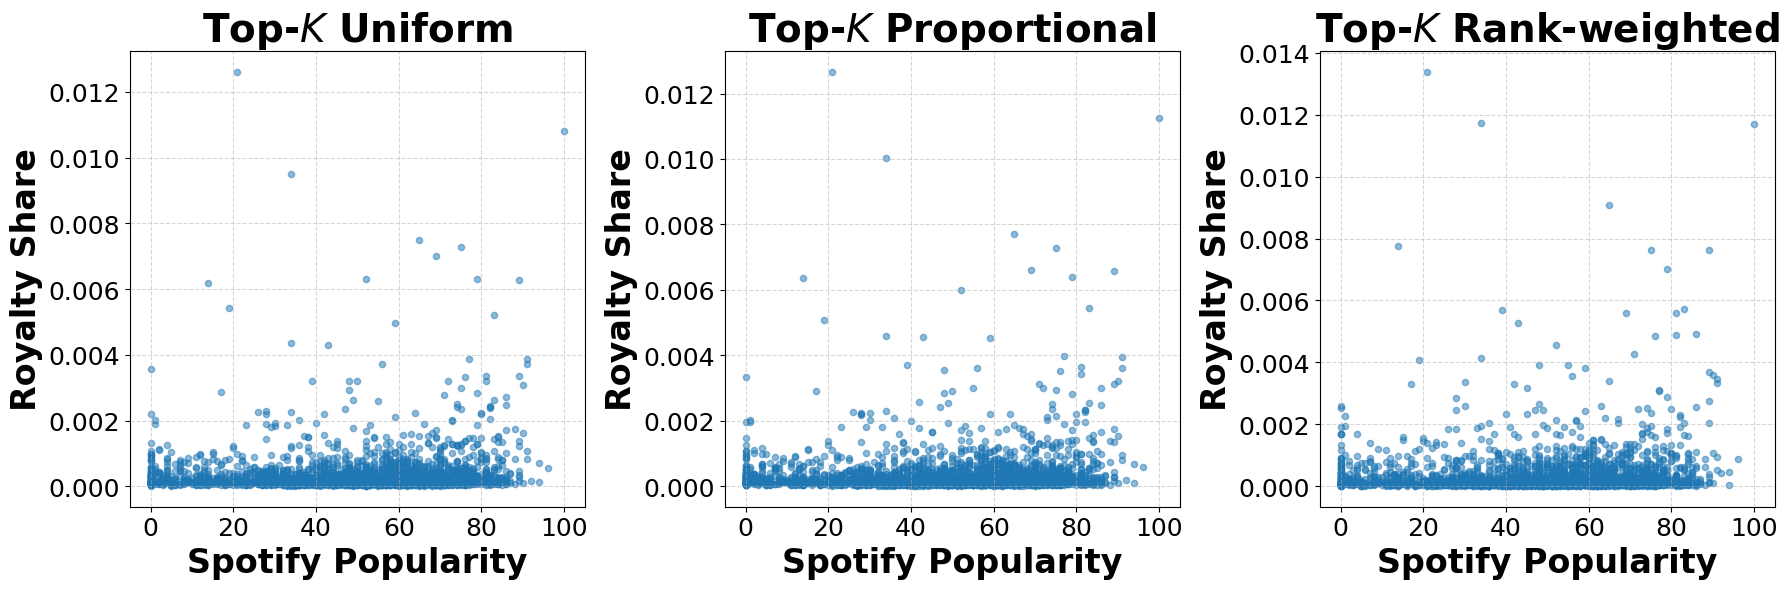

In [47]:
K = 500
methods_to_plot = [
    ("Top-$K$ Uniform", allocate_topk_equal(Spp, k=K, idx_desc=idx_desc)),
    ("Top-$K$ Proportional", allocate_topk_prop(Spp, k=K, idx_desc=idx_desc)),
    ("Top-$K$ Rank-weighted", allocate_inverse_rank(Spp, m=K, p=1.0, idx_desc=idx_desc)),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (method_name, W) in zip(axes, methods_to_plot):
    p = aggregate(W, sample_weights=sample_weights)
    
    royalty_df = pd.DataFrame({
        "id": train_ids.values,
        "user": users.values,
        "royalty": p.detach().cpu().numpy()
    })
    user_royalty = royalty_df.dropna(subset=["user"]).groupby("user", as_index=False)["royalty"].sum()
    user_royalty["royalty_share"] = user_royalty["royalty"] / user_royalty["royalty"].sum()
    user_royalty["spotify_popularity"] = user_royalty["user"].map(popularity_series)
    
    plot_data = user_royalty.dropna(subset=["spotify_popularity"])
    
    ax.scatter(plot_data["spotify_popularity"], plot_data["royalty_share"], s=20, alpha=0.5)
    ax.set_xlabel("Spotify Popularity", fontsize=24, fontweight="bold")
    ax.set_ylabel("Royalty Share", fontsize=24, fontweight="bold")
    ax.set_title(method_name, fontsize=28, fontweight="bold")
    ax.tick_params(axis="both", labelsize=18)
    ax.grid(True, linestyle="--", alpha=0.5)
    
    # if len(plot_data) > 1:
    #     corr = plot_data[["spotify_popularity", "royalty_share"]].corr().iloc[0, 1]
    #     ax.text(0.05, 0.95, f"r = {corr:.3f}", transform=ax.transAxes, fontsize=18,
    #             verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig("royalty_vs_popularity.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
# --- Optional: Save/load popularity data to avoid re-fetching ---
# POPULARITY_CACHE = "artist_popularity_cache.pkl"

# # Save
# import pickle
# with open(POPULARITY_CACHE, "wb") as f:
#     pickle.dump(artist_popularity, f)
# print(f"Saved popularity cache to {POPULARITY_CACHE}")

# To load in future runs, uncomment:
# with open(POPULARITY_CACHE, "rb") as f:
#     artist_popularity = pickle.load(f)
# popularity_series = pd.Series(artist_popularity, name="spotify_popularity")


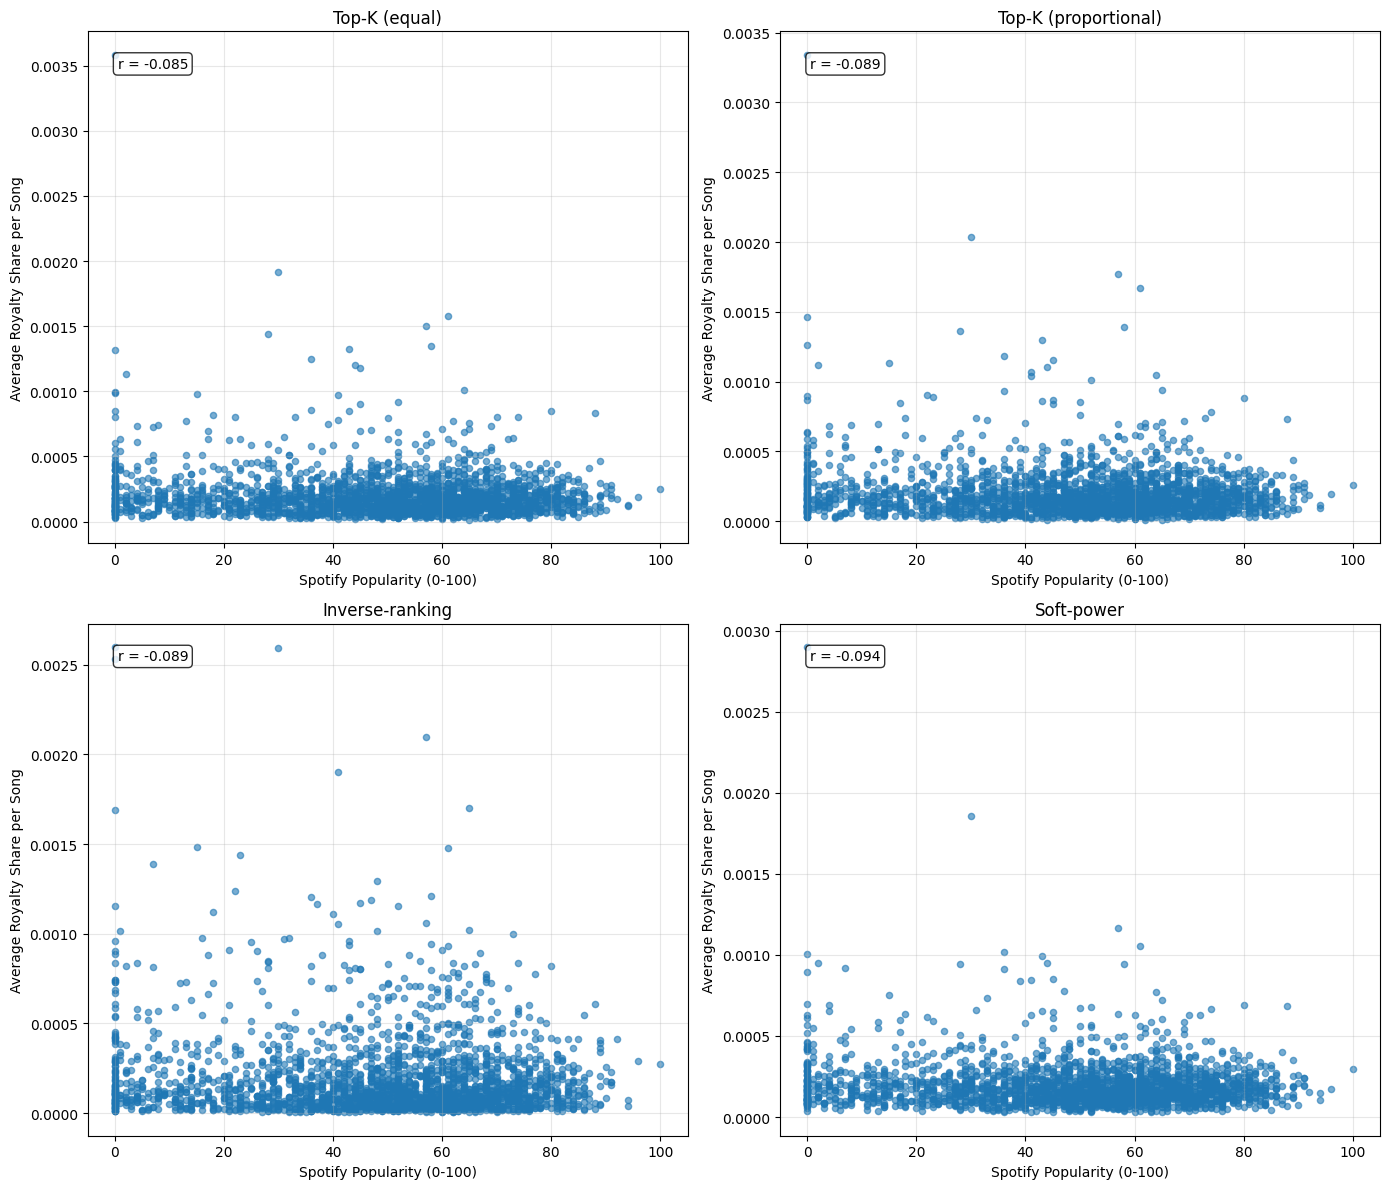


=== Average Share per Song vs Spotify Popularity Correlations ===
Top-K (equal): -0.0846 (n=2343)
Top-K (proportional): -0.0895 (n=2343)
Inverse-ranking: -0.0885 (n=2343)
Soft-power: -0.0945 (n=2343)


In [27]:
# --- Average royalty share per song vs Spotify popularity ---
# For each artist: total_royalty_share / number_of_songs

# Count songs per artist (unique song names in training set)
id_to_song = pd.Series(meta["song"].values, index=meta["ID"].values)
train_df = pd.DataFrame({"id": train_ids.values, "user": users.values})
train_df["song"] = train_df["id"].map(id_to_song)
songs_per_artist = train_df.dropna(subset=["user", "song"]).groupby("user")["song"].nunique()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (method_n, agg_df) in enumerate(user_aggregates.items()):
    # Prepare data
    agg_m = agg_df.copy()
    agg_m["royalty_share"] = agg_m["royalty"] / agg_m["royalty"].sum()
    
    # Add song count and compute average share per song
    agg_m["num_songs"] = agg_m["user"].map(songs_per_artist)
    agg_m["avg_share_per_song"] = agg_m["royalty_share"] / agg_m["num_songs"]
    
    # Merge with popularity
    agg_m["spotify_popularity"] = agg_m["user"].map(popularity_series)
    plot_data = agg_m.dropna(subset=["spotify_popularity", "avg_share_per_song"])
    
    # Scatter plot
    ax = axes[idx]
    ax.scatter(plot_data["spotify_popularity"], plot_data["avg_share_per_song"], s=20, alpha=0.6)
    ax.set_xlabel("Spotify Popularity (0-100)")
    ax.set_ylabel("Average Royalty Share per Song")
    ax.set_title(f"{method_n}")
    ax.grid(True, alpha=0.3)
    
    # Compute correlation if enough data
    if len(plot_data) > 1:
        corr = plot_data[["spotify_popularity", "avg_share_per_song"]].corr().iloc[0, 1]
        ax.text(0.05, 0.95, f"r = {corr:.3f}", transform=ax.transAxes, 
                verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

# Summary statistics
print("\n=== Average Share per Song vs Spotify Popularity Correlations ===")
for method_n, agg_df in user_aggregates.items():
    agg_m = agg_df.copy()
    agg_m["royalty_share"] = agg_m["royalty"] / agg_m["royalty"].sum()
    agg_m["num_songs"] = agg_m["user"].map(songs_per_artist)
    agg_m["avg_share_per_song"] = agg_m["royalty_share"] / agg_m["num_songs"]
    agg_m["spotify_popularity"] = agg_m["user"].map(popularity_series)
    plot_data = agg_m.dropna(subset=["spotify_popularity", "avg_share_per_song"])
    if len(plot_data) > 1:
        corr = plot_data[["spotify_popularity", "avg_share_per_song"]].corr().iloc[0, 1]
        print(f"{method_n}: {corr:.4f} (n={len(plot_data)})")


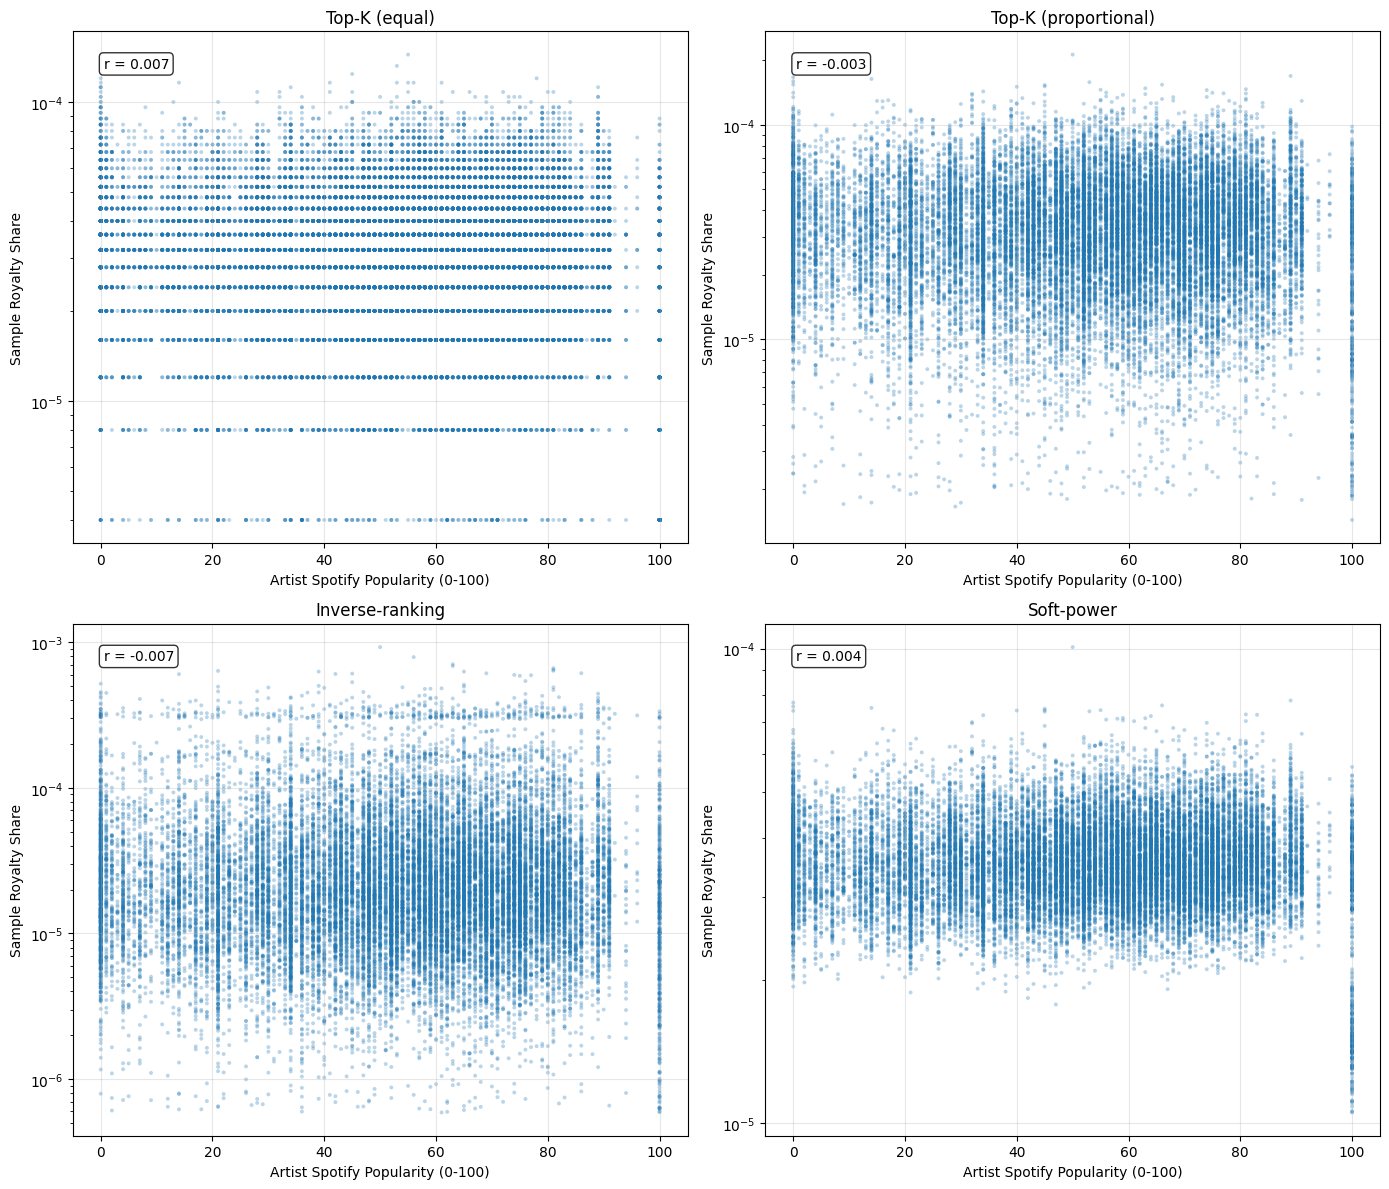


=== Sample-level Royalty Share vs Artist Popularity Correlations ===
Top-K (equal): 0.0065 (n=26226)
Top-K (proportional): -0.0029 (n=26226)
Inverse-ranking: -0.0068 (n=26226)
Soft-power: 0.0038 (n=26226)


In [28]:
# --- Sample-level royalty share vs artist Spotify popularity ---
# For each training sample: its royalty share vs its artist's popularity

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (method_n, obj) in enumerate(results.items()):
    # Get per-sample royalty shares
    p = obj["p"].detach().cpu().numpy()
    
    # Create DataFrame with sample index, royalty, user, and popularity
    sample_df = pd.DataFrame({
        "sample_idx": np.arange(len(p)),
        "royalty_share": p,
        "user": users.values
    })
    
    # Map artist to popularity
    sample_df["spotify_popularity"] = sample_df["user"].map(popularity_series)
    
    # Drop samples without popularity data
    plot_data = sample_df.dropna(subset=["spotify_popularity"])
    
    # Scatter plot
    ax = axes[idx]
    ax.scatter(plot_data["spotify_popularity"], plot_data["royalty_share"], 
               s=8, alpha=0.3, edgecolors='none')
    ax.set_xlabel("Artist Spotify Popularity (0-100)")
    ax.set_ylabel("Sample Royalty Share")
    ax.set_title(f"{method_n}")
    ax.grid(True, alpha=0.3)
    ax.set_yscale("log")  # Log scale for better visualization
    
    # Compute correlation if enough data
    if len(plot_data) > 1:
        corr = plot_data[["spotify_popularity", "royalty_share"]].corr().iloc[0, 1]
        ax.text(0.05, 0.95, f"r = {corr:.3f}", transform=ax.transAxes, 
                verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

# Summary statistics
print("\n=== Sample-level Royalty Share vs Artist Popularity Correlations ===")
for method_n, obj in results.items():
    p = obj["p"].detach().cpu().numpy()
    sample_df = pd.DataFrame({
        "royalty_share": p,
        "user": users.values
    })
    sample_df["spotify_popularity"] = sample_df["user"].map(popularity_series)
    plot_data = sample_df.dropna(subset=["spotify_popularity"])
    if len(plot_data) > 1:
        corr = plot_data[["spotify_popularity", "royalty_share"]].corr().iloc[0, 1]
        print(f"{method_n}: {corr:.4f} (n={len(plot_data)})")
